# School Performance and Deprivation

## Problem Definition and Objectives

The objective of this project is to investigate how regional deprivation affects school performance across England. By analysing Key Stage 4 (GCSE level) results alongside the 2019 Indices of Multiple Deprivation (IMD), we aim to identify the specific socio-economic factors that have the strongest impact on educational outcomes.

### Core Research Questions
1. Performance by Deprivation Level Over Time: How does overall school performance (Attainment 8 / Progress 8) vary between the most and least deprived Local Authorities, and has this attainment gap widened or narrowed between 2019 and 2025?

2. Specific Deprivation Factors: Among the different sub-domains of deprivation (Income, Employment, Health, Crime, Living Environment, Barriers to Housing), which specific factor has the strongest negative correlation with a region's educational outcomes?

3. Subject-Specific Resilience: Are there certain core EBacc subjects (e.g., Maths, Science) that are more resilient to the effects of deprivation compared to others (e.g., Humanities, Languages)?

4. The Gender Gap and Deprivation: How does the performance gap between boys and girls change across different levels of regional deprivation?

5. Language Background and Deprivation: How does the performance of pupils with English as an Additional Language (EAL) compare to first-language English speakers across different deprivation levels?

Machine Learning Questions:

6. Can You Predict a School's Progress 8 Band from Non-Academic Data Alone?

7. What do "over-performing against deprivation" schools have in common — size, type, region, absence rates?



In [2]:
# Core library imports
import os
import requests
import certifi
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

## Data Sourcing

Before we load the data, we will download it directly from the official UK Government sources if it is not already present in our directory. This ensures the notebook is fully reproducible.

Rather than downloading a massive 226MB ZIP file containing dozens of unrelated tables, we download the two relevant datasets directly:

| Dataset | Source | Format |
|---------|--------|--------|
| IMD 2019 (File 7) | Ministry of Housing, Communities & Local Government | Direct CSV |
| KS4 Characteristics & Geography (2019-2025) | Department for Education — Explore Education Statistics API | Direct CSV |

In [3]:
# Create the data folder if it doesn't exist
os.makedirs("data", exist_ok=True)  # makedirs creates the directory "data", and exist_ok=True prevents an error if the folder already exists

# 1. English Indices of Deprivation 2019 (File 7 - LSOA scores, deciles, and denominators)
IoD_URL = "https://assets.publishing.service.gov.uk/media/5dc407b440f0b6379a7acc8d/File_7_-_All_IoD2019_Scores__Ranks__Deciles_and_Population_Denominators_3.csv"
IoD_PATH = "data/File_7_IoD2019.csv" # The path where the IoD 2019 dataset will be saved

# 2. DfE KS4 Pupil Characteristics and Geography dataset (2018/19 up to 2024/25)
KS4_URL = "https://api.education.gov.uk/statistics/v1/data-sets/b3e19901-5d2b-b676-bb4c-e60937d74725/csv"
KS4_PATH = "data/ks4_characteristics_geography.csv" # The path where the KS4 Characteristics & Geography dataset will be saved

# Downloading IoD 2019 dataset
if not os.path.exists(IoD_PATH): # Check if the IoD dataset already exists to avoid unnecessary downloads
    print("Downloading IoD 2019 dataset (File 7)...")
    response = requests.get(IoD_URL) # Send a GET request to the IoD URL to download the dataset
    response.raise_for_status() # Check if the request was successful (status code 200). If not, it will raise an HTTPError.
    with open(IoD_PATH, "wb") as f: # Open the file to save the dataset and close it after writing (using 'with' ensures the file is properly closed)
        f.write(response.content)
    print("Saved data/File_7_IoD2019.csv")
else:
    print("data/File_7_IoD2019.csv already exists.")

# Downloading KS4 Characteristics & Geography dataset
if not os.path.exists(KS4_PATH):
    print("Downloading KS4 Characteristics & Geography dataset...")
    response = requests.get(KS4_URL)
    response.raise_for_status()
    with open(KS4_PATH, "wb") as f:
        f.write(response.content)
    print("Saved data/ks4_characteristics_geography.csv")
else:
    print("data/ks4_characteristics_geography.csv already exists.")

data/File_7_IoD2019.csv already exists.
data/ks4_characteristics_geography.csv already exists.


## Data Loading and Exploration

In this section, we will load our primary datasets:
1. **Indices of Multiple Deprivation (IMD) 2019:** Provides deprivation deciles and sub-domain scores for each Local Authority.
2. **DfE Key Stage 4 Pupil Characteristics and Geography:** Provides performance breakdowns by sex, language, and disadvantage status at Local Authority level from 2018/19 up to 2024/25.

In [4]:
# Load IoD dataset
raw_iod_data = pd.read_csv(IoD_PATH, low_memory=False) # low_memory=False to avoid dtype warnings for large files
iod_data = raw_iod_data.copy()

# Load KS4 Pupil Characteristics and Geography dataset
raw_performance_data = pd.read_csv(KS4_PATH, low_memory=False) # low_memory=False to avoid dtype warnings for large files
performance_data = raw_performance_data.copy()

print(f"IoD shape: {iod_data.shape}")
print(f"KS4 shape: {performance_data.shape}")

IoD shape: (32844, 57)
KS4 shape: (342410, 200)


## Initial Data Inspection

Now that the data is loaded, let's perform an initial inspection to understand the structure, check the column names, and look for any immediate data quality issues.

In [5]:
print("--- IoD 2019 Dataset ---")
iod_data.head()

--- IoD 2019 Dataset ---


,LSOA code (2011),LSOA name (2011),Local Authority District code (2019),Local Authority District name (2019),Index of Multiple Deprivation (IMD) Score,Index of Multiple Deprivation (IMD) Rank (where 1 is most deprived),Index of Multiple Deprivation (IMD) Decile (where 1 is most deprived 10% of LSOAs),Income Score (rate),Income Rank (where 1 is most deprived),Income Decile (where 1 is most deprived 10% of LSOAs),...,Indoors Sub-domain Rank (where 1 is most deprived),Indoors Sub-domain Decile (where 1 is most deprived 10% of LSOAs),Outdoors Sub-domain Score,Outdoors Sub-domain Rank (where 1 is most deprived),Outdoors Sub-domain Decile (where 1 is most deprived 10% of LSOAs),Total population: mid 2015 (excluding prisoners),Dependent Children aged 0-15: mid 2015 (excluding prisoners),Population aged 16-59: mid 2015 (excluding prisoners),Older population aged 60 and over: mid 2015 (excluding prisoners),Working age population 18-59/64: for use with Employment Deprivation Domain (excluding prisoners)
0,E01000001,City of London 001A,E09000001,City of London,6.208,29199,9,0.007,32831,10,...,16364,5,1.503,1615,1,1296,175,656,465,715
1,E01000002,City of London 001B,E09000001,City of London,5.143,30379,10,0.034,29901,10,...,22676,7,1.196,2969,1,1156,182,580,394,620
2,E01000003,City of London 001C,E09000001,City of London,19.402,14915,5,0.086,18510,6,...,17318,6,2.207,162,1,1350,146,759,445,804
3,E01000005,City of London 001E,E09000001,City of London,28.652,8678,3,0.211,6029,2,...,25218,8,1.769,849,1,1121,229,692,200,683
4,E01000006,Barking and Dagenham 016A,E09000002,Barking and Dagenham,19.837,14486,5,0.117,14023,5,...,14745,5,0.969,4368,2,2040,522,1297,221,1285


In [6]:
print("\n---IoD 2019 Info---")
print(iod_data.info())


---IoD 2019 Info---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32844 entries, 0 to 32843
Data columns (total 57 columns):
 #   Column                                                                                              Non-Null Count  Dtype  
---  ------                                                                                              --------------  -----  
 0   LSOA code (2011)                                                                                    32844 non-null  object 
 1   LSOA name (2011)                                                                                    32844 non-null  object 
 2   Local Authority District code (2019)                                                                32844 non-null  object 
 3   Local Authority District name (2019)                                                                32844 non-null  object 
 4   Index of Multiple Deprivation (IMD) Score                                                  

In [7]:
# Find the distinct values on Local Authority District name (2019)
print("\n---Distinct Local Authority District names in IoD 2019---")
print(iod_data["Local Authority District name (2019)"].unique())


---Distinct Local Authority District names in IoD 2019---
['City of London' 'Barking and Dagenham' 'Barnet' 'Bexley' 'Brent'
 'Bromley' 'Camden' 'Croydon' 'Ealing' 'Enfield' 'Greenwich' 'Hackney'
 'Hammersmith and Fulham' 'Haringey' 'Harrow' 'Havering' 'Hillingdon'
 'Hounslow' 'Islington' 'Kensington and Chelsea' 'Kingston upon Thames'
 'Lambeth' 'Lewisham' 'Merton' 'Newham' 'Redbridge' 'Richmond upon Thames'
 'Southwark' 'Sutton' 'Tower Hamlets' 'Waltham Forest' 'Wandsworth'
 'Westminster' 'Bolton' 'Bury' 'Manchester' 'Oldham' 'Rochdale' 'Salford'
 'Stockport' 'Tameside' 'Trafford' 'Wigan' 'Knowsley' 'Liverpool'
 'St. Helens' 'Sefton' 'Wirral' 'Barnsley' 'Doncaster' 'Rotherham'
 'Sheffield' 'Gateshead' 'Newcastle upon Tyne' 'North Tyneside'
 'South Tyneside' 'Sunderland' 'Birmingham' 'Coventry' 'Dudley' 'Sandwell'
 'Solihull' 'Walsall' 'Wolverhampton' 'Bradford' 'Calderdale' 'Kirklees'
 'Leeds' 'Wakefield' 'Hartlepool' 'Middlesbrough' 'Redcar and Cleveland'
 'Stockton-on-Tees' 'Darli

There are 317 local authorities in England

In [8]:

print("\n--- Performance Dataset ---")
performance_data.head()


--- Performance Dataset ---


,time_period,time_identifier,geographic_level,country_code,country_name,region_code,region_name,old_la_code,new_la_code,la_name,...,valueaddedlan_sum,valueaddedlan_average,valueaddedlan_lower_95_ci,valueaddedlan_upper_95_ci,qual_entries_sum,qual_entries_average,gcse_entries_sum,gcse_entries_average,qual_entries_without_discounting_sum,qual_entries_without_discounting_average
0,202425,Academic year,National,E92000001,England,NaN,NaN,NaN,NaN,NaN,...,z,z,z,z,4901678.49,7.8,4525185,7.2,4942447,7.9
1,202425,Academic year,National,E92000001,England,NaN,NaN,NaN,NaN,NaN,...,z,z,z,z,2485577.91,7.8,2286227,7.1,2506494,7.8
2,202425,Academic year,National,E92000001,England,NaN,NaN,NaN,NaN,NaN,...,z,z,z,z,2416100.58,7.9,2238958,7.3,2435953,8
3,202425,Academic year,National,E92000001,England,NaN,NaN,NaN,NaN,NaN,...,z,z,z,z,253719.3,8,235518,7.5,254870,8.1
4,202425,Academic year,National,E92000001,England,NaN,NaN,NaN,NaN,NaN,...,z,z,z,z,123521.17,7.9,113991,7.3,124166,7.9


In [9]:
print("\n--- Performance Info ---")
print(performance_data.info())


--- Performance Info ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 342410 entries, 0 to 342409
Columns: 200 entries, time_period to qual_entries_without_discounting_average
dtypes: float64(10), int64(4), object(186)
memory usage: 522.5+ MB
None


In [10]:
# list of columns in datasets
print("\n--- IoD Columns ---")
print(iod_data.columns.tolist()) # Convert columns to list for better readability

print("\n--- Performance Columns ---")
print(performance_data.columns.tolist()) # Convert columns to list for better readability


--- IoD Columns ---
['LSOA code (2011)', 'LSOA name (2011)', 'Local Authority District code (2019)', 'Local Authority District name (2019)', 'Index of Multiple Deprivation (IMD) Score', 'Index of Multiple Deprivation (IMD) Rank (where 1 is most deprived)', 'Index of Multiple Deprivation (IMD) Decile (where 1 is most deprived 10% of LSOAs)', 'Income Score (rate)', 'Income Rank (where 1 is most deprived)', 'Income Decile (where 1 is most deprived 10% of LSOAs)', 'Employment Score (rate)', 'Employment Rank (where 1 is most deprived)', 'Employment Decile (where 1 is most deprived 10% of LSOAs)', 'Education, Skills and Training Score', 'Education, Skills and Training Rank (where 1 is most deprived)', 'Education, Skills and Training Decile (where 1 is most deprived 10% of LSOAs)', 'Health Deprivation and Disability Score', 'Health Deprivation and Disability Rank (where 1 is most deprived)', 'Health Deprivation and Disability Decile (where 1 is most deprived 10% of LSOAs)', 'Crime Score', 'C

In [11]:
#distinct values in geographic_level column of performance dataset
print("\n--- Geographic Level Distinct Values ---")
print(performance_data['geographic_level'].unique()) 


--- Geographic Level Distinct Values ---
['National' 'Regional' 'Local authority']


We will have to isolate the dataset to Local Authority level later on

In [12]:
# Get the unique values for breakdown_topic in the performance dataset
print("\n--- Unique Breakdown Topics in Performance Dataset ---")
print(performance_data['breakdown_topic'].unique()) # Get unique values in the 'breakdown_topic' column to understand the different categories of breakdowns available in the dataset




--- Unique Breakdown Topics in Performance Dataset ---
['Total' 'Sex' 'Ethnicity' 'Sex by ethnicity' 'FSM status'
 'Sex by FSM status' 'Ethnicity by FSM status'
 'Sex by ethnicity by FSM status' 'SEN provision' 'Sex by SEN provision'
 'Ethnicity by SEN provision' 'Sex by ethnicity by SEN provision'
 'FSM status by SEN provision' 'Sex by FSM status by SEN provision'
 'SEN primary need' 'Sex by SEN primary need' 'Disadvantage status'
 'Sex by disadvantage status' 'Ethnicity by disadvantage status'
 'Sex by ethnicity by disadvantage status'
 'SEN provision by disadvantage status'
 'Sex by SEN provision by disadvantage status'
 'Ethnicity by SEN provision by disadvantage status'
 'Sex by ethnicity by SEN provision by disadvantage status'
 'First language' 'Sex by first language' 'Ethnicity by first language'
 'Sex by ethnicity by first language' 'FSM status by first language'
 'Sex by FSM status by first language' 'SEN provision by first language'
 'Sex by SEN provision by first language'

We will use the aggregates for Gender (Sex), Disadvantage (Disadvantage status), FSM (FSM status), and Language (First language) later on for Q4 and Q5

In [13]:
# Get the unique values for Sex in the performance dataset
print("\n--- Unique Sex Categories in Performance Dataset ---")
print(performance_data['sex'].unique()) # Get unique values in the 'sex' column to understand the different categories of sex available in the dataset


--- Unique Sex Categories in Performance Dataset ---
['Total' 'Boys' 'Girls']


In [14]:
# Get the unique values for Disadvantage_status in the performance dataset
print("\n--- Unique Disadvantage Status Categories in Performance Dataset ---")
print(performance_data['disadvantage_status'].unique()) # Get unique values in the 'disadvantage_status' column to understand the different categories of disadvantage status available in the dataset


--- Unique Disadvantage Status Categories in Performance Dataset ---
['Total' 'Disadvantaged' 'Not known to be disadvantaged']


In [15]:
# Get the unique values for FSM_status in the performance dataset
print("\n--- Unique FSM Status Categories in Performance Dataset ---")
print(performance_data['fsm_status'].unique()) # Get unique values in the 'fsm_status' column to understand the different categories of FSM status available in the dataset


--- Unique FSM Status Categories in Performance Dataset ---
['Total' 'FSM eligible' 'Not known to be FSM eligible']


In [16]:
# Get the unique values for first language in the performance dataset
print("\n--- Unique First Language Categories in Performance Dataset ---")
print(performance_data['first_language'].unique()) # Get unique values in the 'first_language' column to understand the different categories of first language available in the dataset


--- Unique First Language Categories in Performance Dataset ---
['Total' 'Known or believed to be English'
 'Known or believed to be other than English']


In [17]:
#statistics for IoD and KS4 datasets
print("\n--- IoD 2019 Dataset Statistics ---")
print(iod_data.describe())
print("\n--- KS4 Dataset Statistics ---")
print(performance_data.describe())


--- IoD 2019 Dataset Statistics ---
       Index of Multiple Deprivation (IMD) Score  \
count                               32844.000000   
mean                                   21.669393   
std                                    15.332229   
min                                     0.541000   
25%                                     9.913750   
50%                                    17.647500   
75%                                    29.583000   
max                                    92.735000   

       Index of Multiple Deprivation (IMD) Rank (where 1 is most deprived)  \
count                                       32844.000000                     
mean                                        16422.499208                     
std                                          9481.390454                     
min                                             1.000000                     
25%                                          8211.750000                     
50%                       

## Data Selection and Feature Engineering

Based on our research questions, we need to narrow down the hundreds of columns in these datasets. Below is our mapping of the specific columns we need for our analysis:

## Data Selection – Variables Retained for Analysis

To address the five research questions, the original datasets were reduced substantially from approximately 200 performance variables and 57 deprivation variables to only those directly relevant to measuring educational outcomes, demographic differences, and deprivation indicators.

---

### Performance Dataset (`ks4_characteristics_geography.csv`)

The performance dataset contains Local Authority level Key Stage 4 outcomes. Variables retained differ depending on whether the analysis focuses on overall trends, subject-specific performance, or demographic breakdowns.

### Core Variables Retained (Used Across All Research Questions)

| Column        | Purpose                                                     | Research Question(s) |
| ------------- | ----------------------------------------------------------- | -------------------- |
| `time_period` | Academic year used for trend analysis (2019–2025)           | Q1–Q5                |
| `new_la_code` | Local Authority identifier used for merging datasets        | Q1–Q5                |
| `la_name`     | Local Authority name for interpretation and visualisation   | Q1–Q5                |
| `pupil_count` | Population size used for weighting and handling suppression | Q1–Q5                |

---

### Overall Performance Variables (Used Primarily for Q1 & Q2)

These variables measure overall educational attainment and progress and are used to examine how educational outcomes vary across deprivation levels.

| Column                | Description                       | Research Question(s) |
| --------------------- | --------------------------------- | -------------------- |
| `attainment8_average` | Average Attainment 8 score        | Q1, Q2, Q4, Q5       |
| `progress8_average`   | Average Progress 8 score          | Q1, Q2, Q4, Q5       |
| `ebacc_aps_average`   | Overall EBacc Average Point Score | Q1, Q4, Q5           |

---

### Subject-Specific Performance Variables (Used for Q3)

These variables allow investigation into whether certain subjects are more resilient to deprivation effects than others.

| Column                     | Description                    | Research Question(s) |
| -------------------------- | ------------------------------ | -------------------- |
| `attainment8eng_average`   | Attainment 8 English component | Q3                   |
| `attainment8mat_average`   | Attainment 8 Maths component   | Q3                   |
| `attainment8ebacc_average` | Attainment 8 EBacc component   | Q3                   |
| `progress8eng_average`     | Progress 8 English component   | Q3                   |
| `progress8mat_average`     | Progress 8 Maths component     | Q3                   |
| `progress8ebacc_average`   | Progress 8 EBacc component     | Q3                   |
| `progress8open_average`    | Progress 8 Open component      | Q3                   |
| `ebacceng_aps_average`     | EBacc English APS              | Q3                   |
| `ebaccmat_aps_average`     | EBacc Maths APS                | Q3                   |
| `ebaccsci_aps_average`     | EBacc Science APS              | Q3                   |
| `ebacchum_aps_average`     | EBacc Humanities APS           | Q3                   |
| `ebacclan_aps_average`     | EBacc Languages APS            | Q3                   |

---

### Demographic Variables (Used for Q4 & Q5)

These variables allow comparison between demographic groups across deprivation levels.

| Column                | Description                                | Research Question(s) |
| --------------------- | ------------------------------------------ | -------------------- |
| `breakdown_topic`     | Indicates demographic grouping type        | Q4, Q5               |
| `sex`                 | Gender grouping variable                   | Q4                   |
| `disadvantage_status` | Disadvantaged / non-disadvantaged grouping | Supporting analysis  |
| `fsm_status`          | Free school meal eligibility grouping      | Supporting analysis  |
| `first_language`      | First language / EAL grouping variable     | Q5                   |
| `pupil_count`         | Number of pupils within subgroup           | Q4, Q5               |
| `attainment8_average` | Average Attainment 8 score by subgroup     | Q4, Q5               |
| `progress8_average`   | Average Progress 8 score by subgroup       | Q4, Q5               |
| `ebacc_aps_average`   | Average EBacc APS by subgroup              | Q4, Q5               |

---

## Deprivation Dataset (`File_7_IoD2019.csv`)

The deprivation dataset provides Local Authority measures used to quantify regional socioeconomic disadvantage and investigate which factors most strongly relate to educational outcomes.

| Column                                                             | Description                                 | Research Question(s) |
| ------------------------------------------------------------------ | ------------------------------------------- | -------------------- |
| `Local Authority District code (2019)`                             | Local Authority identifier used for merging | Q1–Q5                |
| `Local Authority District name (2019)`                             | Local Authority name                        | Q1–Q5                |
| `Index of Multiple Deprivation (IMD) Score`                        | Overall deprivation measure                 | Q1                   |
| `Income Score (rate)`                                              | Income deprivation indicator                | Q2                   |
| `Employment Score (rate)`                                          | Employment deprivation indicator            | Q2                   |
| `Health Deprivation and Disability Score`                          | Health deprivation indicator                | Q2                   |
| `Crime Score`                                                      | Crime deprivation indicator                 | Q2                   |
| `Barriers to Housing and Services Score`                           | Housing accessibility indicator             | Q2                   |
| `Living Environment Score`                                         | Environmental deprivation indicator         | Q2                   |
| `Income Deprivation Affecting Children Index (IDACI) Score (rate)` | Child poverty indicator                     | Q2                   |
| `Children and Young People Sub-domain Score`                       | Education-related deprivation measure       | Q2                   |

---

> **Data Reduction Note:**
> All other variables from both datasets were removed to reduce dimensionality and retain only variables directly relevant to the research questions. The deprivation dataset is originally reported at Lower Super Output Area (LSOA) level and is aggregated to Local Authority level using an ONS lookup table before merging with performance data.


### Isolating Local Authority Data

First, we filter the KS4 dataset to only include data at the Local Authority level, as our deprivation data is mapped to Local Authorities.

In [18]:
# Filter performance data to Local authority level
df_loc = performance_data[performance_data["geographic_level"] == "Local authority"].copy()

df_loc.head()

,time_period,time_identifier,geographic_level,country_code,country_name,region_code,region_name,old_la_code,new_la_code,la_name,...,valueaddedlan_sum,valueaddedlan_average,valueaddedlan_lower_95_ci,valueaddedlan_upper_95_ci,qual_entries_sum,qual_entries_average,gcse_entries_sum,gcse_entries_average,qual_entries_without_discounting_sum,qual_entries_without_discounting_average
5939,202425,Academic year,Local authority,E92000001,England,E12000001,North East,805.0,E06000001,Hartlepool,...,z,z,z,z,8213.71,7.3,7227,6.4,8262,7.4
5940,202425,Academic year,Local authority,E92000001,England,E12000001,North East,805.0,E06000001,Hartlepool,...,z,z,z,z,4147.03,7.3,3662,6.4,4178,7.3
5941,202425,Academic year,Local authority,E92000001,England,E12000001,North East,805.0,E06000001,Hartlepool,...,z,z,z,z,4066.68,7.3,3565,6.4,4084,7.4
5942,202425,Academic year,Local authority,E92000001,England,E12000001,North East,805.0,E06000001,Hartlepool,...,z,z,z,z,132,7.8,124,7.3,132,7.8
5943,202425,Academic year,Local authority,E92000001,England,E12000001,North East,805.0,E06000001,Hartlepool,...,z,z,z,z,75,7.5,70,7,75,7.5


In [19]:
df_loc.shape

(293223, 200)

We have isolated the dataset to Local Authority level. Next, we will create the base dataset for Q1, Q2, and Q3, picking the overall and subject-specific metrics.

### Creating the Overall and Subject-Specific Dataset (Q1, Q2, Q3)

We extract overall measures (`attainment8_average`, `progress8_average`) and subject-specific measures. We use the `Total` breakdown here, meaning we are looking at the overall student population in that area, not split by gender or disadvantage.

In [20]:
cols_total = [
    'time_period',
    'new_la_code',
    'la_name',
    'pupil_count',
    'attainment8_average',
    'progress8_average',
    'ebacc_aps_average',
    'attainment8eng_average', 
    'attainment8mat_average', 
    'attainment8ebacc_average', 
    'progress8eng_average', 
    'progress8mat_average', 
    'progress8ebacc_average', 
    'progress8open_average', 
    'ebacceng_aps_average', 
    'ebaccmat_aps_average', 
    'ebaccsci_aps_average', 
    'ebacchum_aps_average', 
    'ebacclan_aps_average'
]

# Filter to 'Total' breakdown
df_total = df_loc[df_loc["breakdown_topic"] == "Total"].copy()
df_total = df_total[cols_total]

# Check the shape
print("Shape of Q1/Q2/Q3 dataset:", df_total.shape)

Shape of Q1/Q2/Q3 dataset: (1058, 19)


In [21]:
df_total.head()

,time_period,new_la_code,la_name,pupil_count,attainment8_average,progress8_average,ebacc_aps_average,attainment8eng_average,attainment8mat_average,attainment8ebacc_average,progress8eng_average,progress8mat_average,progress8ebacc_average,progress8open_average,ebacceng_aps_average,ebaccmat_aps_average,ebaccsci_aps_average,ebacchum_aps_average,ebacclan_aps_average
5939,202425,E06000001,Hartlepool,1123,42.4,z,3.66,9.5,8.2,11.9,z,z,z,z,4.76,4.1,4.16,3.34,1.45
6169,202425,E06000002,Middlesbrough,1594,41.1,z,3.55,9.2,8,11.5,z,z,z,z,4.59,3.99,3.94,3.37,1.48
6415,202425,E06000003,Redcar and Cleveland,1510,44.4,z,3.94,9.9,8.8,12.6,z,z,z,z,4.92,4.39,4.24,3.84,2.03
6644,202425,E06000004,Stockton-on-Tees,2305,45,z,3.97,10.1,8.9,12.6,z,z,z,z,5.03,4.47,4.26,3.77,2.03
6887,202425,E06000005,Darlington,1212,44.3,z,3.83,9.7,8.7,12.5,z,z,z,z,4.83,4.37,4.16,3.3,2.13


In [22]:
df_total.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1058 entries, 5939 to 342131
Data columns (total 19 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   time_period               1058 non-null   int64 
 1   new_la_code               1058 non-null   object
 2   la_name                   1058 non-null   object
 3   pupil_count               1058 non-null   int64 
 4   attainment8_average       1058 non-null   object
 5   progress8_average         1058 non-null   object
 6   ebacc_aps_average         1058 non-null   object
 7   attainment8eng_average    1058 non-null   object
 8   attainment8mat_average    1058 non-null   object
 9   attainment8ebacc_average  1058 non-null   object
 10  progress8eng_average      1058 non-null   object
 11  progress8mat_average      1058 non-null   object
 12  progress8ebacc_average    1058 non-null   object
 13  progress8open_average     1058 non-null   object
 14  ebacceng_aps_average    

### Handling Missing Data and Data Types

In [23]:
# Count total values, z values, and percentage of z values
z_summary = pd.DataFrame({
    'total_values': df_total.count(),
    'z_count': (df_total == 'z').sum()
})

# Calculate percentage of z values
z_summary['z_percentage'] = (
    z_summary['z_count'] / z_summary['total_values']
) * 100

# Round percentages
z_summary['z_percentage'] = z_summary['z_percentage'].round(2)

# Display results
z_summary

,total_values,z_count,z_percentage
time_period,1058,0,0.00
new_la_code,1058,0,0.00
la_name,1058,0,0.00
pupil_count,1058,0,0.00
attainment8_average,1058,0,0.00
progress8_average,1058,453,42.82
ebacc_aps_average,1058,0,0.00
attainment8eng_average,1058,0,0.00
attainment8mat_average,1058,0,0.00
attainment8ebacc_average,1058,0,0.00


In [24]:
# Look at the data set that contains a z value in any column
df_z = df_total[df_total.isin(['z']).any(axis=1)]
df_z

,time_period,new_la_code,la_name,pupil_count,attainment8_average,progress8_average,ebacc_aps_average,attainment8eng_average,attainment8mat_average,attainment8ebacc_average,progress8eng_average,progress8mat_average,progress8ebacc_average,progress8open_average,ebacceng_aps_average,ebaccmat_aps_average,ebaccsci_aps_average,ebacchum_aps_average,ebacclan_aps_average
5939,202425,E06000001,Hartlepool,1123,42.4,z,3.66,9.5,8.2,11.9,z,z,z,z,4.76,4.1,4.16,3.34,1.45
6169,202425,E06000002,Middlesbrough,1594,41.1,z,3.55,9.2,8,11.5,z,z,z,z,4.59,3.99,3.94,3.37,1.48
6415,202425,E06000003,Redcar and Cleveland,1510,44.4,z,3.94,9.9,8.8,12.6,z,z,z,z,4.92,4.39,4.24,3.84,2.03
6644,202425,E06000004,Stockton-on-Tees,2305,45,z,3.97,10.1,8.9,12.6,z,z,z,z,5.03,4.47,4.26,3.77,2.03
6887,202425,E06000005,Darlington,1212,44.3,z,3.83,9.7,8.7,12.5,z,z,z,z,4.83,4.37,4.16,3.3,2.13
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
296440,201920,E10000029,Suffolk,7413,48.4,z,4.18,10,9.4,14.1,z,z,z,z,4.99,4.7,4.67,4.16,1.92
296702,201920,E10000030,Surrey,10734,53.6,z,4.76,10.9,10.5,15.9,z,z,z,z,5.46,5.23,5.24,4.58,2.81
296979,201920,E10000031,Warwickshire,5990,52.6,z,4.64,10.8,10.3,15.3,z,z,z,z,5.38,5.15,5.09,4.38,2.79
297257,201920,E10000032,West Sussex,8199,50.3,z,4.41,10.3,9.7,14.9,z,z,z,z,5.11,4.86,4.97,4.05,2.49


In [25]:
df_z.info()

<class 'pandas.core.frame.DataFrame'>
Index: 453 entries, 5939 to 297539
Data columns (total 19 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   time_period               453 non-null    int64 
 1   new_la_code               453 non-null    object
 2   la_name                   453 non-null    object
 3   pupil_count               453 non-null    int64 
 4   attainment8_average       453 non-null    object
 5   progress8_average         453 non-null    object
 6   ebacc_aps_average         453 non-null    object
 7   attainment8eng_average    453 non-null    object
 8   attainment8mat_average    453 non-null    object
 9   attainment8ebacc_average  453 non-null    object
 10  progress8eng_average      453 non-null    object
 11  progress8mat_average      453 non-null    object
 12  progress8ebacc_average    453 non-null    object
 13  progress8open_average     453 non-null    object
 14  ebacceng_aps_average     

All Progress 8 variables have about **453 missing values (around 42.82%, shown as "z")**.

This level of missing data is too high for reliable analysis, especially for:
- correlations with deprivation
- comparisons over time (2019–2025)
- comparisons across Local Authorities

Keeping these variables could lead to biased or misleading results.

As a result, all Progress 8 variables were removed from the dataset.

We now focus on:
- Attainment 8 measures  
- EBacc Average Point Score (APS)  
- Subject-specific attainment measures  

This improves the reliability and completeness of the analysis.

In [26]:
progress_cols = [
    'progress8_average',
    'progress8eng_average',
    'progress8mat_average',
    'progress8ebacc_average',
    'progress8open_average'
]

df_total = df_total.drop(columns=progress_cols)

In [27]:
df_total.head()

,time_period,new_la_code,la_name,pupil_count,attainment8_average,ebacc_aps_average,attainment8eng_average,attainment8mat_average,attainment8ebacc_average,ebacceng_aps_average,ebaccmat_aps_average,ebaccsci_aps_average,ebacchum_aps_average,ebacclan_aps_average
5939,202425,E06000001,Hartlepool,1123,42.4,3.66,9.5,8.2,11.9,4.76,4.1,4.16,3.34,1.45
6169,202425,E06000002,Middlesbrough,1594,41.1,3.55,9.2,8,11.5,4.59,3.99,3.94,3.37,1.48
6415,202425,E06000003,Redcar and Cleveland,1510,44.4,3.94,9.9,8.8,12.6,4.92,4.39,4.24,3.84,2.03
6644,202425,E06000004,Stockton-on-Tees,2305,45,3.97,10.1,8.9,12.6,5.03,4.47,4.26,3.77,2.03
6887,202425,E06000005,Darlington,1212,44.3,3.83,9.7,8.7,12.5,4.83,4.37,4.16,3.3,2.13


In [28]:
df_total.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1058 entries, 5939 to 342131
Data columns (total 14 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   time_period               1058 non-null   int64 
 1   new_la_code               1058 non-null   object
 2   la_name                   1058 non-null   object
 3   pupil_count               1058 non-null   int64 
 4   attainment8_average       1058 non-null   object
 5   ebacc_aps_average         1058 non-null   object
 6   attainment8eng_average    1058 non-null   object
 7   attainment8mat_average    1058 non-null   object
 8   attainment8ebacc_average  1058 non-null   object
 9   ebacceng_aps_average      1058 non-null   object
 10  ebaccmat_aps_average      1058 non-null   object
 11  ebaccsci_aps_average      1058 non-null   object
 12  ebacchum_aps_average      1058 non-null   object
 13  ebacclan_aps_average      1058 non-null   object
dtypes: int64(2), object(12)


Some performance columns are currently stored as text (`str`) even though they contain numbers.

These will be converted to `float` so we can use them for calculations, graphs, and analysis.

In [29]:
cols_to_float = [
    'attainment8_average',
    'ebacc_aps_average',
    'attainment8eng_average',
    'attainment8mat_average',
    'attainment8ebacc_average',
    'ebacceng_aps_average',
    'ebaccmat_aps_average',
    'ebaccsci_aps_average',
    'ebacchum_aps_average',
    'ebacclan_aps_average'
]

df_total[cols_to_float] = df_total[cols_to_float].astype(float)

# Checking datatypes to ensure they are now float64
print(df_total.dtypes)

time_period                   int64
new_la_code                  object
la_name                      object
pupil_count                   int64
attainment8_average         float64
ebacc_aps_average           float64
attainment8eng_average      float64
attainment8mat_average      float64
attainment8ebacc_average    float64
ebacceng_aps_average        float64
ebaccmat_aps_average        float64
ebaccsci_aps_average        float64
ebacchum_aps_average        float64
ebacclan_aps_average        float64
dtype: object


Data types are now correctly set to `float64`, allowing numerical analysis.

We will now create an `end_year` column from `time_period` to make the time variable easier to interpret and use in trend analysis and visualisation.

In [30]:
df_total['end_year'] = 2000 + df_total['time_period'].astype(str).str[4:].astype(int)

In [31]:
df_total.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1058 entries, 5939 to 342131
Data columns (total 15 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   time_period               1058 non-null   int64  
 1   new_la_code               1058 non-null   object 
 2   la_name                   1058 non-null   object 
 3   pupil_count               1058 non-null   int64  
 4   attainment8_average       1058 non-null   float64
 5   ebacc_aps_average         1058 non-null   float64
 6   attainment8eng_average    1058 non-null   float64
 7   attainment8mat_average    1058 non-null   float64
 8   attainment8ebacc_average  1058 non-null   float64
 9   ebacceng_aps_average      1058 non-null   float64
 10  ebaccmat_aps_average      1058 non-null   float64
 11  ebaccsci_aps_average      1058 non-null   float64
 12  ebacchum_aps_average      1058 non-null   float64
 13  ebacclan_aps_average      1058 non-null   float64
 14  end_year

In [32]:
df_total.describe()

,time_period,pupil_count,attainment8_average,ebacc_aps_average,attainment8eng_average,attainment8mat_average,attainment8ebacc_average,ebacceng_aps_average,ebaccmat_aps_average,ebaccsci_aps_average,ebacchum_aps_average,ebacclan_aps_average,end_year
count,1058.000000,1058.000000,1058.000000,1058.000000,1058.000000,1058.000000,1058.000000,1058.000000,1058.000000,1058.000000,1058.000000,1058.000000,1058.000000
mean,202123.050095,3886.676749,47.909168,4.206664,10.141210,9.335728,13.935444,5.050000,4.667826,4.613497,3.913251,2.381711,2022.010397
std,202.021155,2942.098065,4.359867,0.461329,0.795828,0.849247,1.485579,0.400849,0.424707,0.455158,0.508176,0.724659,2.000209
min,201819.000000,14.000000,33.300000,2.770000,7.400000,6.400000,9.000000,3.660000,3.190000,3.020000,2.250000,0.470000,2019.000000
25%,201920.000000,2160.250000,45.000000,3.900000,9.600000,8.800000,12.925000,4.790000,4.400000,4.300000,3.570000,1.880000,2020.000000
50%,202122.000000,3026.500000,47.400000,4.140000,10.100000,9.200000,13.800000,5.010000,4.615000,4.560000,3.860000,2.190000,2022.000000
75%,202324.000000,4296.000000,50.500000,4.460000,10.600000,9.800000,14.900000,5.280000,4.920000,4.910000,4.250000,2.767500,2024.000000
max,202425.000000,18596.000000,62.000000,5.680000,12.600000,12.200000,18.500000,6.290000,6.120000,6.100000,5.510000,4.520000,2025.000000


In [33]:
# Check how many unique local authority names there are
print("\n--- Unique Local Authority Names ---")
print(df_total['la_name'].nunique()) # Get the number of unique local authority names in the 'la_name' column of the df_total dataset


--- Unique Local Authority Names ---
154


### Creating Demographic Gap Datasets (Q4 & Q5)

We extract separate dataframes for Gender (`Sex`), Disadvantage (`Disadvantage status`), FSM (`FSM status`), and Language (`First language`).

In [34]:
df_gender = df_loc[df_loc["breakdown_topic"] == "Sex"].copy()
df_disadv = df_loc[df_loc["breakdown_topic"] == "Disadvantage status"].copy()
df_fsm = df_loc[df_loc["breakdown_topic"] == "FSM status"].copy()
df_lang = df_loc[df_loc["breakdown_topic"] == "First language"].copy()

# Check the shapes of the filtered datasets
print(f"Gender dataset shape: {df_gender.shape}")
print(f"Disadvantage dataset shape: {df_disadv.shape}")
print(f"FSM dataset shape: {df_fsm.shape}")
print(f"Language dataset shape: {df_lang.shape}")

Gender dataset shape: (2116, 200)
Disadvantage dataset shape: (2116, 200)
FSM dataset shape: (2114, 200)
Language dataset shape: (2109, 200)


In [35]:
df_gender.head()

,time_period,time_identifier,geographic_level,country_code,country_name,region_code,region_name,old_la_code,new_la_code,la_name,...,valueaddedlan_sum,valueaddedlan_average,valueaddedlan_lower_95_ci,valueaddedlan_upper_95_ci,qual_entries_sum,qual_entries_average,gcse_entries_sum,gcse_entries_average,qual_entries_without_discounting_sum,qual_entries_without_discounting_average
5940,202425,Academic year,Local authority,E92000001,England,E12000001,North East,805.0,E06000001,Hartlepool,...,z,z,z,z,4147.03,7.3,3662,6.4,4178,7.3
5941,202425,Academic year,Local authority,E92000001,England,E12000001,North East,805.0,E06000001,Hartlepool,...,z,z,z,z,4066.68,7.3,3565,6.4,4084,7.4
6170,202425,Academic year,Local authority,E92000001,England,E12000001,North East,806.0,E06000002,Middlesbrough,...,z,z,z,z,5590.68,7,4786,6,5672,7.1
6171,202425,Academic year,Local authority,E92000001,England,E12000001,North East,806.0,E06000002,Middlesbrough,...,z,z,z,z,5787.68,7.2,4977,6.2,5859,7.3
6416,202425,Academic year,Local authority,E92000001,England,E12000001,North East,807.0,E06000003,Redcar and Cleveland,...,z,z,z,z,5542,7.2,4720,6.1,5596,7.2


#### Trimming Demographic Datasets to Relevant Columns

Just as with `df_total`, we now reduce each demographic dataframe from 200 columns down to only those needed for Q4 and Q5. We keep:

- **Core identifiers**: `time_period`, `new_la_code`, `la_name`, `pupil_count`
- **Demographic label**: the specific breakdown column for each dataframe (`sex`, `disadvantage_status`, `fsm_status`, or `first_language`)
- **Performance metrics**: the same attainment and subject-level averages used in `df_total`

Note: Progress 8 columns are excluded for the same reason as in `df_total` — ~43% missing values (`z`) make them unreliable for analysis.

In [36]:
# Core identifier columns shared across all demographic dataframes
core_cols = [
    'time_period',
    'new_la_code',
    'la_name',
    'pupil_count',
]

# Performance metric columns (same set as df_total, Progress 8 excluded)
perf_cols = [
    'attainment8_average',
    'ebacc_aps_average',
    'attainment8eng_average',
    'attainment8mat_average',
    'attainment8ebacc_average',
    'ebacceng_aps_average',
    'ebaccmat_aps_average',
    'ebaccsci_aps_average',
    'ebacchum_aps_average',
    'ebacclan_aps_average',
]

# Trim each demographic dataframe to relevant columns only
df_gender = df_gender[core_cols + ['sex']                 + perf_cols].copy()
df_disadv = df_disadv[core_cols + ['disadvantage_status'] + perf_cols].copy()
df_fsm    = df_fsm   [core_cols + ['fsm_status']          + perf_cols].copy()
df_lang   = df_lang  [core_cols + ['first_language']       + perf_cols].copy()

print(f"df_gender: {df_gender.shape[0]} rows, {df_gender.shape[1]} columns")
print(f"df_disadv: {df_disadv.shape[0]} rows, {df_disadv.shape[1]} columns")
print(f"df_fsm:    {df_fsm.shape[0]} rows, {df_fsm.shape[1]} columns")
print(f"df_lang:   {df_lang.shape[0]} rows, {df_lang.shape[1]} columns")

df_gender: 2116 rows, 15 columns
df_disadv: 2116 rows, 15 columns
df_fsm:    2114 rows, 15 columns
df_lang:   2109 rows, 15 columns


In [37]:
df_gender.head()

,time_period,new_la_code,la_name,pupil_count,sex,attainment8_average,ebacc_aps_average,attainment8eng_average,attainment8mat_average,attainment8ebacc_average,ebacceng_aps_average,ebaccmat_aps_average,ebaccsci_aps_average,ebacchum_aps_average,ebacclan_aps_average
5940,202425,E06000001,Hartlepool,569,Boys,40.5,3.54,9,8.3,11.6,4.47,4.13,4.1,3.21,1.23
5941,202425,E06000001,Hartlepool,554,Girls,44.5,3.79,10.1,8.2,12.2,5.06,4.08,4.23,3.47,1.68
6170,202425,E06000002,Middlesbrough,794,Boys,39.5,3.45,8.6,8.2,11.3,4.27,4.1,3.94,3.22,1.24
6171,202425,E06000002,Middlesbrough,800,Girls,42.6,3.65,9.8,7.8,11.7,4.9,3.88,3.94,3.51,1.71
6416,202425,E06000003,Redcar and Cleveland,773,Boys,42.6,3.82,9.2,8.9,12.4,4.57,4.46,4.24,3.71,1.72


In [38]:
df_gender.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2116 entries, 5940 to 342133
Data columns (total 15 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   time_period               2116 non-null   int64 
 1   new_la_code               2116 non-null   object
 2   la_name                   2116 non-null   object
 3   pupil_count               2116 non-null   int64 
 4   sex                       2116 non-null   object
 5   attainment8_average       2116 non-null   object
 6   ebacc_aps_average         2116 non-null   object
 7   attainment8eng_average    2116 non-null   object
 8   attainment8mat_average    2116 non-null   object
 9   attainment8ebacc_average  2116 non-null   object
 10  ebacceng_aps_average      2116 non-null   object
 11  ebaccmat_aps_average      2116 non-null   object
 12  ebaccsci_aps_average      2116 non-null   object
 13  ebacchum_aps_average      2116 non-null   object
 14  ebacclan_aps_average    

In [39]:
# Convert performance columns from str to float (same treatment as df_total)
for df in [df_gender, df_disadv, df_fsm, df_lang]:
    df[perf_cols] = df[perf_cols].apply(pd.to_numeric, errors='coerce')

# Add end_year column derived from time_period (e.g. 202425 -> 2025)
for df in [df_gender, df_disadv, df_fsm, df_lang]:
    df['end_year'] = 2000 + df['time_period'].astype(str).str[4:].astype(int)

# Verify dtypes on one dataframe as a spot-check
print(df_gender.dtypes)

time_period                   int64
new_la_code                  object
la_name                      object
pupil_count                   int64
sex                          object
attainment8_average         float64
ebacc_aps_average           float64
attainment8eng_average      float64
attainment8mat_average      float64
attainment8ebacc_average    float64
ebacceng_aps_average        float64
ebaccmat_aps_average        float64
ebaccsci_aps_average        float64
ebacchum_aps_average        float64
ebacclan_aps_average        float64
end_year                      int64
dtype: object


In [40]:
# count the unique new_la_code values and la_name values to check for consistency
print("\n--- Unique Local Authority Codes ---")
print(df_total['new_la_code'].nunique()) # Get the number of unique local authority codes in the 'new_la_code' column of the df_total dataset
print("\n--- Unique Local Authority Names ---")
print(df_total['la_name'].nunique()) # Get the number of unique local authority names in the 'la_name' column of the df_total dataset


--- Unique Local Authority Codes ---
157

--- Unique Local Authority Names ---
154


As there are more unique local authority codes and only 154 unique local authority names, this implies that there are duplicate rows, or that some values have been deleted or modified. 

In [41]:
code_name_map = df_total.groupby('new_la_code')['la_name'].nunique()
print("Codes with multiple names:")
print(code_name_map[code_name_map > 1])

name_code_map = df_total.groupby('la_name')['new_la_code'].nunique()
print("\nNames with multiple codes:")
print(name_code_map[name_code_map > 1])

Codes with multiple names:
Series([], Name: la_name, dtype: int64)

Names with multiple codes:
la_name
Buckinghamshire    2
North Yorkshire    2
Somerset           2
Name: new_la_code, dtype: int64


So it appears that there are three local authorities with multiple codes:

- Buckinghamshire,
- North Yorkshire, and
- Somerset

These three local authories all had their boundaries redrawn during the timeframe we are analysing, and so have different codes. As the boundaries mean that there may be different schools included at different times, it is most justifiable to drop the rows with the older codes (starting with E10).


In [42]:
duplicate_las = ['Buckinghamshire', 'North Yorkshire', 'Somerset']

old_codes = (
    df_total[df_total['la_name'].isin(duplicate_las)]
    .groupby(['la_name', 'new_la_code'])['end_year']
    .min()
    .reset_index()
    .sort_values(['la_name', 'end_year'])
)
print(old_codes)

codes_to_drop = old_codes.groupby('la_name').first()['new_la_code'].tolist()

for df in [df_total, df_gender, df_disadv, df_fsm, df_lang]:
    before = len(df)
    df.drop(df[df['new_la_code'].isin(codes_to_drop)].index, inplace=True)
    print(f"Dropped {before - len(df)} rows")

           la_name new_la_code  end_year
1  Buckinghamshire   E10000002      2019
0  Buckinghamshire   E06000060      2020
3  North Yorkshire   E10000023      2019
2  North Yorkshire   E06000065      2023
5         Somerset   E10000027      2019
4         Somerset   E06000066      2023
Dropped 9 rows
Dropped 18 rows
Dropped 18 rows
Dropped 18 rows
Dropped 18 rows


After converting to float (which ran as coerced), any z values changed to NaN. Any remaining NaN need analysis at this point.

In [43]:
for name, df in [('df_total', df_total), 
                 ('df_gender', df_gender),
                 ('df_disadv', df_disadv), 
                 ('df_fsm', df_fsm), 
                 ('df_lang', df_lang)]:
    print(f"--- {name} ---")
    null_counts = df.isnull().sum()
    null_counts = null_counts[null_counts > 0]
    if len(null_counts) == 0:
        print("No missing values")
    else:
        total = len(df)
        print(pd.DataFrame({
            'missing': null_counts,
            'percent': (null_counts / total * 100).round(2)
        }))

--- df_total ---
No missing values
--- df_gender ---
No missing values
--- df_disadv ---
                      missing  percent
ebacchum_aps_average        1     0.05
ebacclan_aps_average        4     0.19
--- df_fsm ---
                      missing  percent
ebacchum_aps_average        1     0.05
ebacclan_aps_average        5     0.24
--- df_lang ---
No missing values


Several datasets have no missing data, including df_total, df_gender, and df_lang. The two datasets which do contain missing values, have a very low level of missingness (<0.25%).

If these are missing across different LA's and different years, then it is likely random, and we can justify filling in with the group median. However, if it is the same LA, then it is structural missingness and this data should be dropped (and acknowledged).

In [44]:
# df_disadv
print("=== df_disadv missing ===")
print(df_disadv[df_disadv['ebacchum_aps_average'].isnull() | 
                df_disadv['ebacclan_aps_average'].isnull()]
      [['la_name', 'end_year', 'disadvantage_status', 
        'ebacchum_aps_average', 'ebacclan_aps_average']])

# df_fsm
print("\n--- df_fsm missing ---")
print(df_fsm[df_fsm['ebacchum_aps_average'].isnull() | 
             df_fsm['ebacclan_aps_average'].isnull()]
     [['la_name', 'end_year', 'fsm_status',
       'ebacchum_aps_average', 'ebacclan_aps_average']])

for name, df in [('df_total', df_total), ('df_gender', df_gender),
                 ('df_disadv', df_disadv), ('df_fsm', df_fsm), 
                 ('df_lang', df_lang)]:
    count = (df['la_name'] == 'Isles of Scilly').sum()
    print(f"{name}: {count} Isles of Scilly rows")

=== df_disadv missing ===
                la_name  end_year disadvantage_status  ebacchum_aps_average  \
18068   Isles of Scilly      2025       Disadvantaged                  3.00   
66394   Isles of Scilly      2024       Disadvantaged                  5.00   
170883  Isles of Scilly      2022       Disadvantaged                   NaN   
315960  Isles of Scilly      2019       Disadvantaged                  2.33   

        ebacclan_aps_average  
18068                    NaN  
66394                    NaN  
170883                   NaN  
315960                   NaN  

--- df_fsm missing ---
                la_name  end_year    fsm_status  ebacchum_aps_average  \
18048   Isles of Scilly      2025  FSM eligible                   3.0   
66371   Isles of Scilly      2024  FSM eligible                   5.0   
118722  Isles of Scilly      2023  FSM eligible                   5.0   
222582  Isles of Scilly      2021  FSM eligible                   9.0   
315943  Isles of Scilly      2019 

In both datasets, it is the Isles of Scilly that have the missing data. This is a very small local authority (total population of ~2,000 people). This is likely to be the reason for  the observed missing data: systematic suppression of subject-level data arising from small cohort sizes. 

For consistency, therefore, it is also dropped from the primary dataset to ensure consistency across research questions. 

In [45]:
for df in [df_total, df_gender, df_disadv, df_fsm, df_lang]:
    before = len(df)
    df.drop(df[df['la_name'] == 'Isles of Scilly'].index, inplace=True)
    print(f"Dropped {before - len(df)} rows")

Dropped 7 rows
Dropped 14 rows
Dropped 14 rows
Dropped 12 rows
Dropped 7 rows


# Aggregation of IOD data

This dataset needs to be aggregated by Local Authority District code.

In [46]:
iod_la = iod_data.groupby(
    ['Local Authority District code (2019)', 'Local Authority District name (2019)']
).agg(
    imd_score          = ('Index of Multiple Deprivation (IMD) Score', 'mean'),
    income_score       = ('Income Score (rate)', 'mean'),
    employment_score   = ('Employment Score (rate)', 'mean'),
    health_score       = ('Health Deprivation and Disability Score', 'mean'),
    crime_score        = ('Crime Score', 'mean'),
    barriers_score     = ('Barriers to Housing and Services Score', 'mean'),
    living_env_score   = ('Living Environment Score', 'mean'),
    idaci_score        = ('Income Deprivation Affecting Children Index (IDACI) Score (rate)', 'mean'),
    children_subdomain = ('Children and Young People Sub-domain Score', 'mean'),
).reset_index()

iod_la.rename(columns={
    'Local Authority District code (2019)': 'la_code',
    'Local Authority District name (2019)': 'la_name_iod'
}, inplace=True)

print("---NEW DEPRIVATION DATA STRUCTURE ------")
print(iod_la.head(10))
print(iod_la.info())

---NEW DEPRIVATION DATA STRUCTURE ------
     la_code                  la_name_iod  imd_score  income_score  \
0  E06000001                   Hartlepool  34.853121      0.226241   
1  E06000002                Middlesbrough  40.443116      0.251326   
2  E06000003         Redcar and Cleveland  29.841330      0.185534   
3  E06000004             Stockton-on-Tees  25.244108      0.161017   
4  E06000005                   Darlington  26.787000      0.160000   
5  E06000006                       Halton  32.875684      0.188089   
6  E06000007                   Warrington  18.955480      0.109142   
7  E06000008        Blackburn with Darwen  35.813626      0.209462   
8  E06000009                    Blackpool  45.907638      0.251500   
9  E06000010  Kingston upon Hull, City of  40.335066      0.225886   

   employment_score  health_score  crime_score  barriers_score  \
0          0.182017      0.874190     0.582345       13.764345   
1          0.190605      1.192070     0.680523       14.

Now that this dataset is aggregated, it is necessary to check how well the LA's in the aggregated IOD dataset map to the LA's in the performance data.

In [47]:
perf_codes = set(df_total['new_la_code'].unique())
iod_codes  = set(iod_la['la_code'].unique())

print(f"Performance LAs:     {len(perf_codes)}")
print(f"IoD LAs:             {len(iod_codes)}")
print(f"Matching:            {len(perf_codes & iod_codes)}")
print(f"In perf, not IoD:    {len(perf_codes - iod_codes)}")
print(f"In IOD, not perf:    {len(iod_codes - perf_codes)}")
print()
print("Performance LAs not found in IoD:")
unmatched = df_total[df_total['new_la_code'].isin(perf_codes - iod_codes)]\
    [['new_la_code', 'la_name']].drop_duplicates()
print(unmatched.to_string(index=False))

Performance LAs:     153
IoD LAs:             317
Matching:            123
In perf, not IoD:    30
In IOD, not perf:    194

Performance LAs not found in IoD:
new_la_code                 la_name
  E06000060         Buckinghamshire
  E06000061  North Northamptonshire
  E06000062   West Northamptonshire
  E06000063              Cumberland
  E06000064 Westmorland and Furness
  E06000065         North Yorkshire
  E06000066                Somerset
  E10000003          Cambridgeshire
  E10000007              Derbyshire
  E10000008                   Devon
  E10000011             East Sussex
  E10000012                   Essex
  E10000013         Gloucestershire
  E10000014               Hampshire
  E10000015           Hertfordshire
  E10000016                    Kent
  E10000017              Lancashire
  E10000018          Leicestershire
  E10000019            Lincolnshire
  E10000020                 Norfolk
  E10000024         Nottinghamshire
  E10000025             Oxfordshire
  E10000028  

There is not good matching between the datasets currently. There are 30 LA's in the performance dataset that are not in the IOD dataset, while there are 194 LA's in the IOD dataset not in the performance dataset.

### Downloading the ONS Lookup Table

There are different geo levels in datasets, we need look up table which match la codes with la/district codes.

We will download the `Look_up.csv` directly from an official source if it doesn't exist in our `data/` folder yet.

In [48]:
lookup_path = "data/Look_up.csv"

if not os.path.exists(lookup_path):
    print("Downloading ONS Lookup Table...")

    url = (
        "https://hub.arcgis.com/api/v3/datasets/"
        "fdddaa25a0df4679b496620557cca534_0/downloads/data"
        "?format=csv&spatialRefId=4326"
    )

    df = pd.read_csv(url)
    df.to_csv(lookup_path, index=False)

    print("Download complete!")
else:
    print("Look_up.csv already exists in the data/ folder.")

Look_up.csv already exists in the data/ folder.


In [49]:
df_lookup = pd.read_csv('data/Look_up.csv')
df_lookup.head()

,FID,LTLA19CD,LTLA19NM,UTLA19CD,UTLA19NM
0,1,E08000002,Bury,E08000002,Bury
1,2,E06000001,Hartlepool,E06000001,Hartlepool
2,3,E08000003,Manchester,E08000003,Manchester
3,4,E08000004,Oldham,E08000004,Oldham
4,5,E06000002,Middlesbrough,E06000002,Middlesbrough


The lookup table is ready. We can now load it and merge it into our Deprivation dataset so that the IMD scores are tagged with a matching `UTLA16CD` code.

### Mapping IMD Data using Lookup Table

We merge the lookup table into our IMD data so we can map `Local Authority District code (2019)` to the higher level County codes.

In [50]:
# Load lookup table
df_lookup = pd.read_csv('data/Look_up.csv')

# Merge IMD district data with lookup
imd_lookup = iod_data.merge(
    df_lookup,
    left_on="Local Authority District code (2019)",
    right_on="LTLA19CD",
    how="inner" # AL changed to inner so that only keep rows with full data, not ones with e.g. perf but not deprivation
)

print("Merged IMD with Lookup shape:", imd_lookup.shape)

Merged IMD with Lookup shape: (32844, 62)


In [51]:
# Check the merged dataset
imd_lookup.head()

,LSOA code (2011),LSOA name (2011),Local Authority District code (2019),Local Authority District name (2019),Index of Multiple Deprivation (IMD) Score,Index of Multiple Deprivation (IMD) Rank (where 1 is most deprived),Index of Multiple Deprivation (IMD) Decile (where 1 is most deprived 10% of LSOAs),Income Score (rate),Income Rank (where 1 is most deprived),Income Decile (where 1 is most deprived 10% of LSOAs),...,Total population: mid 2015 (excluding prisoners),Dependent Children aged 0-15: mid 2015 (excluding prisoners),Population aged 16-59: mid 2015 (excluding prisoners),Older population aged 60 and over: mid 2015 (excluding prisoners),Working age population 18-59/64: for use with Employment Deprivation Domain (excluding prisoners),FID,LTLA19CD,LTLA19NM,UTLA19CD,UTLA19NM
0,E01000001,City of London 001A,E09000001,City of London,6.208,29199,9,0.007,32831,10,...,1296,175,656,465,715,68,E09000001,City of London,E09000001,City of London
1,E01000002,City of London 001B,E09000001,City of London,5.143,30379,10,0.034,29901,10,...,1156,182,580,394,620,68,E09000001,City of London,E09000001,City of London
2,E01000003,City of London 001C,E09000001,City of London,19.402,14915,5,0.086,18510,6,...,1350,146,759,445,804,68,E09000001,City of London,E09000001,City of London
3,E01000005,City of London 001E,E09000001,City of London,28.652,8678,3,0.211,6029,2,...,1121,229,692,200,683,68,E09000001,City of London,E09000001,City of London
4,E01000006,Barking and Dagenham 016A,E09000002,Barking and Dagenham,19.837,14486,5,0.117,14023,5,...,2040,522,1297,221,1285,69,E09000002,Barking and Dagenham,E09000002,Barking and Dagenham


In [52]:
# Check for missing values in the LTLA19CD column after the merge
imd_lookup["LTLA19CD"].isna().sum()

np.int64(0)

In [53]:
# Check for missing values in the LAD19CD column after the merge
iod_data["Local Authority District code (2019)"].nunique() 

317

In [54]:
# checking that IMD and merged dataset have the same amount of LA districts
imd_lookup["LTLA19CD"].nunique()

317

The lookup codes are attached. However, the IMD data is at the LSOA (neighbourhood) level. We must aggregate it up to the Local Authority level by taking the mean of all LSOAs in each area.

### Aggregating Deprivation Data (LSOA to Local Authority)

We group the IMD data by `UTLA16CD` and `UTLA16NM` and use `.agg()` to take the mean of each specific deprivation factor.

In [55]:
imd_la = (
    imd_lookup
    .groupby(["UTLA19CD", "UTLA19NM"], as_index=False)
    .agg({
        "Index of Multiple Deprivation (IMD) Score": "mean",
        "Income Score (rate)": "mean",
        "Employment Score (rate)": "mean",
        "Health Deprivation and Disability Score": "mean",
        "Crime Score": "mean",
        "Barriers to Housing and Services Score": "mean",
        "Living Environment Score": "mean",
        "Income Deprivation Affecting Children Index (IDACI) Score (rate)": "mean",
        "Children and Young People Sub-domain Score": "mean"
    })
)

print(f"Aggregated IMD rows: {len(imd_la)}")
print(imd_la.head())

Aggregated IMD rows: 151
    UTLA19CD              UTLA19NM  Index of Multiple Deprivation (IMD) Score  \
0  E06000001            Hartlepool                                  34.853121   
1  E06000002         Middlesbrough                                  40.443116   
2  E06000003  Redcar and Cleveland                                  29.841330   
3  E06000004      Stockton-on-Tees                                  25.244108   
4  E06000005            Darlington                                  26.787000   

   Income Score (rate)  Employment Score (rate)  \
0             0.226241                 0.182017   
1             0.251326                 0.190605   
2             0.185534                 0.162909   
3             0.161017                 0.132700   
4             0.160000                 0.131477   

   Health Deprivation and Disability Score  Crime Score  \
0                                 0.874190     0.582345   
1                                 1.192070     0.680523   
2   

The IMD data is now aggregated to the exact same geographic level as our KS4 datasets. The final step is to merge them together.

## Final Dataset Merging

We now merge our aggregated `imd_la` data with our various performance dataframes (`df_total`, `df_gender`, etc.) to create our final analytical datasets.

In [56]:
# Final dataset for Q1, Q2, and Q3
final_df_total = df_total.merge(
    imd_la,
    left_on="new_la_code",
    right_on="UTLA19CD",
    how="inner"
)

# Final demographic datasets (Q4 & Q5)
final_df_gender = df_gender.merge(imd_la, left_on="new_la_code", right_on="UTLA19CD", how="inner")
final_df_disadv = df_disadv.merge(imd_la, left_on="new_la_code", right_on="UTLA19CD", how="inner")
final_df_fsm = df_fsm.merge(imd_la, left_on="new_la_code", right_on="UTLA19CD", how="inner")
final_df_lang = df_lang.merge(imd_la, left_on="new_la_code", right_on="UTLA19CD", how="inner")

print("Final Total Dataset shape:", final_df_total.shape)

# checking for missing IMD matches after merge
print("Missing IMD matches:", final_df_total["Index of Multiple Deprivation (IMD) Score"].isna().sum())

Final Total Dataset shape: (1014, 26)
Missing IMD matches: 0


In [57]:
final_df_total.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1014 entries, 0 to 1013
Data columns (total 26 columns):
 #   Column                                                            Non-Null Count  Dtype  
---  ------                                                            --------------  -----  
 0   time_period                                                       1014 non-null   int64  
 1   new_la_code                                                       1014 non-null   object 
 2   la_name                                                           1014 non-null   object 
 3   pupil_count                                                       1014 non-null   int64  
 4   attainment8_average                                               1014 non-null   float64
 5   ebacc_aps_average                                                 1014 non-null   float64
 6   attainment8eng_average                                            1014 non-null   float64
 7   attainment8mat_average           

The names of the columns are in several cases unwieldy, and therefore are renamed.

In [58]:
imd_rename = {
    "Index of Multiple Deprivation (IMD) Score": "imd_score",
    "Income Score (rate)": "income_score",
    "Employment Score (rate)": "employment_score",
    "Health Deprivation and Disability Score": "health_score",
    "Crime Score": "crime_score",
    "Barriers to Housing and Services Score": "barriers_score",
    "Living Environment Score": "living_env_score",
    "Income Deprivation Affecting Children Index (IDACI) Score (rate)": "idaci_score",
    "Children and Young People Sub-domain Score": "children_subdomain"
}

for df in [final_df_total, final_df_gender, final_df_disadv,
           final_df_fsm, final_df_lang]:
    df.rename(columns=imd_rename, inplace=True)

# Confirm the rename worked
print("IMD columns present:", [c for c in final_df_total.columns if c in imd_rename.values()])

IMD columns present: ['imd_score', 'income_score', 'employment_score', 'health_score', 'crime_score', 'barriers_score', 'living_env_score', 'idaci_score', 'children_subdomain']


In [59]:
missing_imd = final_df_total[final_df_total['imd_score'].isna()]\
    [['new_la_code', 'la_name']].drop_duplicates()

print(f"LAs with no deprivation data after merge: {len(missing_imd)}")
print(missing_imd)

LAs with no deprivation data after merge: 0
Empty DataFrame
Columns: [new_la_code, la_name]
Index: []


In [60]:
# Save final_df_total, final_df_gender, final_df_disadv, final_df_fsm, final_df_lang to CSV files for use in the next notebook
final_df_total.to_csv("data/final_df_total.csv", index=False)
final_df_gender.to_csv("data/final_df_gender.csv", index=False)
final_df_disadv.to_csv("data/final_df_disadv.csv", index=False)
final_df_fsm.to_csv("data/final_df_fsm.csv", index=False)
final_df_lang.to_csv("data/final_df_lang.csv", index=False)

# Exploratory Data Analysis

We now need to explore the distributions of each of the columns, in order to identify outliers and anomalies, and identify any patterns and the overall structure of the distributions. 

In [64]:
for df in [final_df_total, final_df_gender, final_df_disadv, final_df_fsm, final_df_lang]:
    print(f'\n---Description of {df} dataframe---')
    df.describe()


---Description of       time_period new_la_code               la_name  pupil_count  \
0          202425   E06000001            Hartlepool         1123   
1          202425   E06000002         Middlesbrough         1594   
2          202425   E06000003  Redcar and Cleveland         1510   
3          202425   E06000004      Stockton-on-Tees         2305   
4          202425   E06000005            Darlington         1212   
...           ...         ...                   ...          ...   
1009       201819   E10000029               Suffolk         6972   
1010       201819   E10000030                Surrey        10388   
1011       201819   E10000031          Warwickshire         5623   
1012       201819   E10000032           West Sussex         8002   
1013       201819   E10000034        Worcestershire         5439   

      attainment8_average  ebacc_aps_average  attainment8eng_average  \
0                    42.4               3.66                     9.5   
1                   

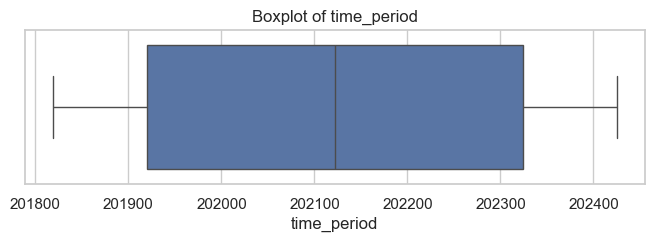

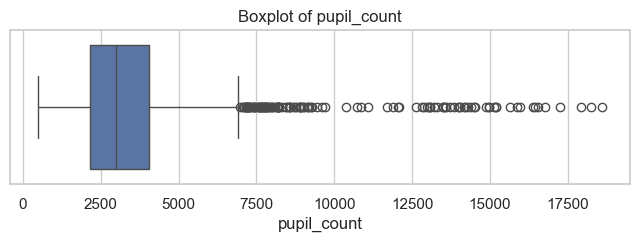

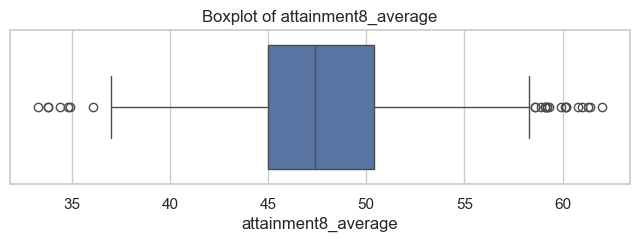

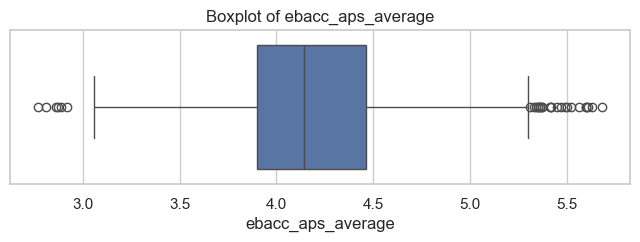

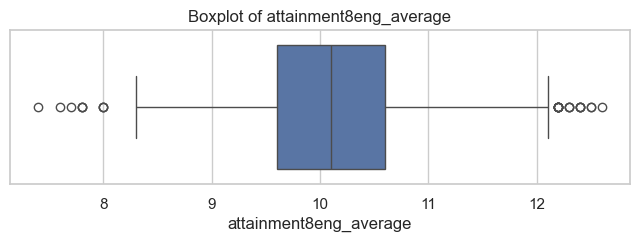

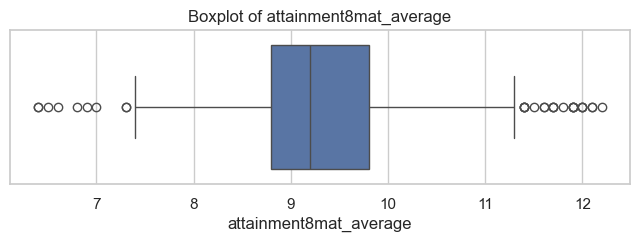

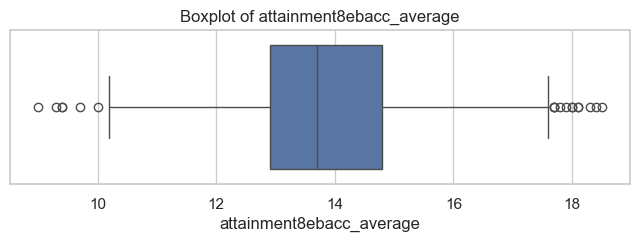

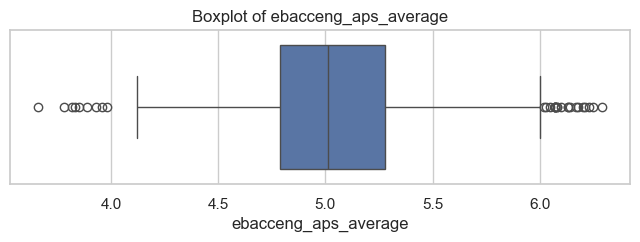

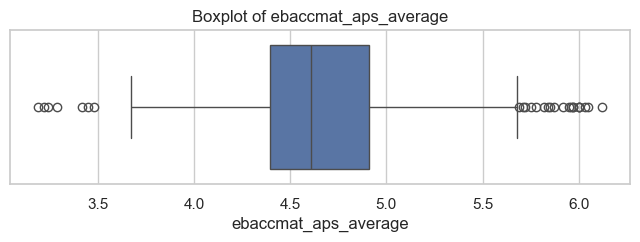

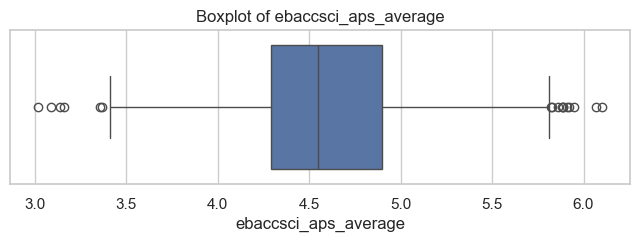

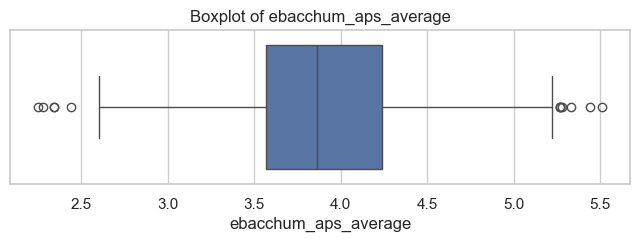

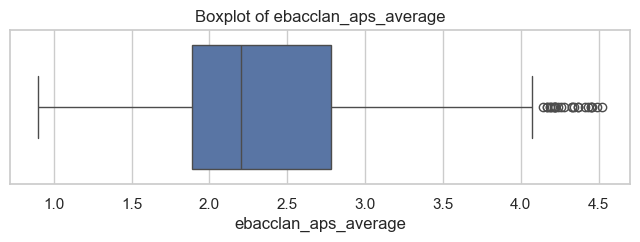

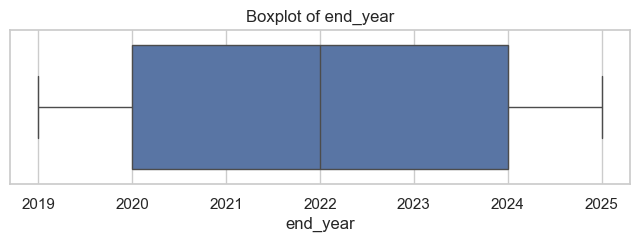

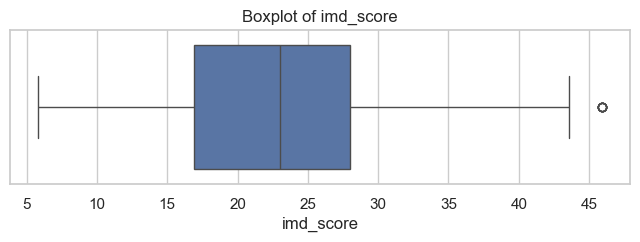

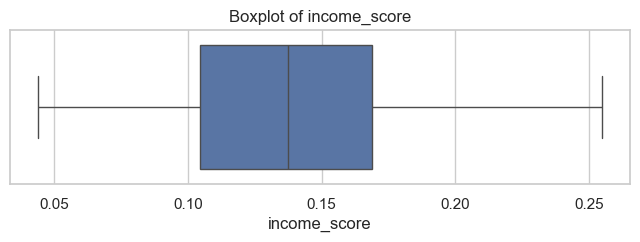

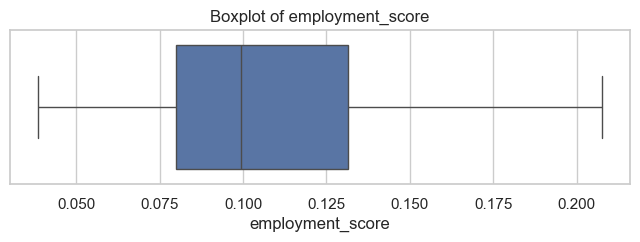

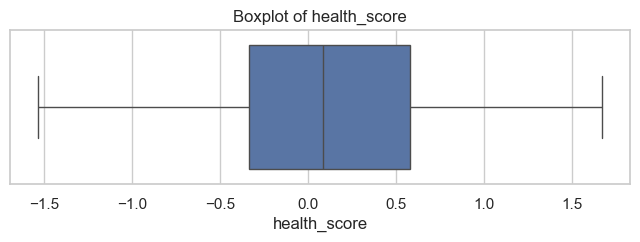

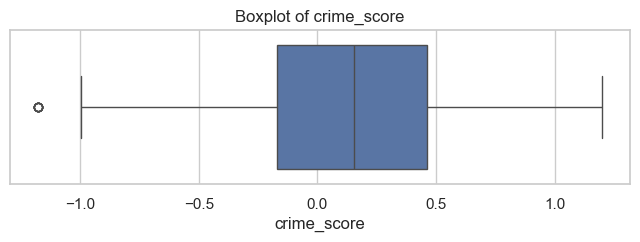

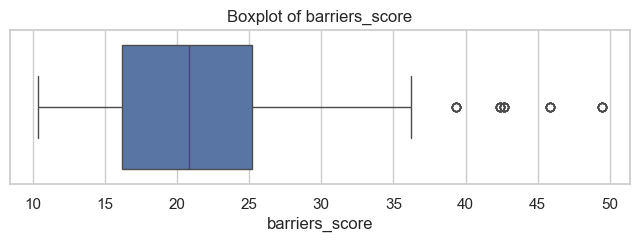

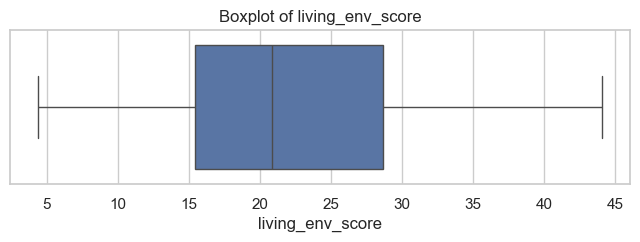

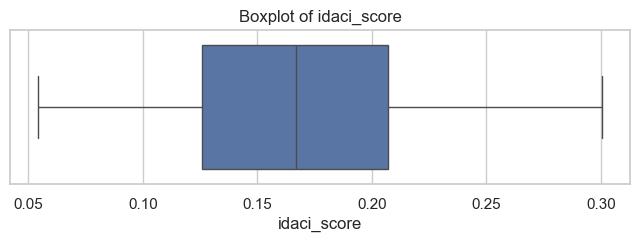

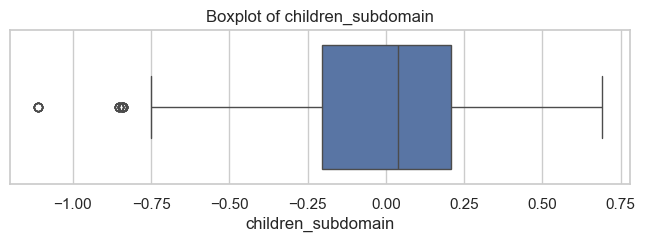

In [63]:
# Exploratory Data Analysis
sns.set_theme(style="whitegrid")

exploring_numeric_df = final_df_total.select_dtypes(exclude=['object'])

for column in exploring_numeric_df.columns:
    plt.figure(figsize=(8, 2))
    sns.boxplot(x=exploring_numeric_df[column])
    plt.title(f'Boxplot of {column}')
    plt.show()

### Interpreting the boxplots

It is important firstly to note the differences in scales between the different boxplots. Some of these differences are evident - year, pupil count etc. However, several calculated scores appear to be normalised to be on a centred z-score-type scale (roughly -1.5 to +1.5), including `children_subdomain`, `health_score`, and `crime_score`. However, other deprivation scores do not appear to be normalised: `imd_score`, `barriers_score`, `living_env_score` are on raw scales (ranging from 5-50). These will need to be appropriately scaled.

#### Outliers

Several outliers can be observed in the above boxplots. Of most note are:

- imd_score: There is a single point significantly visually separated from the rest. This is likely to be a high leverage point and may distort any analysis of correlation between this measure and any educational outcomes. It is important to identify this single point and run regressions with and without this single point to see whether it changes the conclusions.

- barriers_score: There is a cluster of a few outliers close together. This is worth investigating as a sub-group of note - it could be, for example, a group of London LA's, where it is sometimes claimed that there is high achievement versus deprivation, or some other grouping of LA's with common features that may also show commonalities in educational outcomes. So it is worth investigating this sub-group further.

- children_subdomain: There is a single very low reading, and another cluster of slightly less negative values. Both the invidual outlier and sub-group may also show structural differences in these LA performances and should be investigated further.

- Outliers in the educational outcomes tend to be on the upper end of the scale. It is worth investigating these by year, as our timeframe included the Covid years when teacher assessed grades were in some cases inflated and caused a distortion in the grade boundaries and outcomes. As with the deprivation outliers, it is also useful to investigate if any of these are consistently associated with specific LA's. 